In [27]:

import numpy
import tifffile
import os
from matplotlib import pyplot
from skimage.transform import resize
from tiffwrapper import make_composite

import sys
sys.path.insert(0, "..")

from figure import get_ground_truth_images, get_predicted_images, load_images, get_raw_images

methods = [
    "CARE2D",
    "N2V",
    "pix2pix",
    "UNet-RCAN",
    "IMAGENET1K_V1",
    "JUMP",
    "HPA",
    "SIM",
    "STED",
]
dataset = "ov-lqhq-mt"

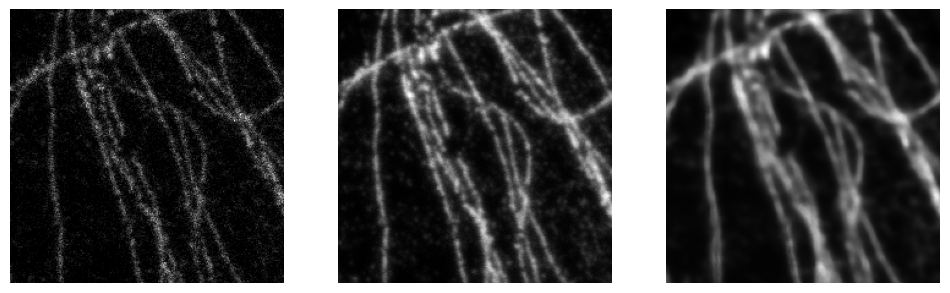

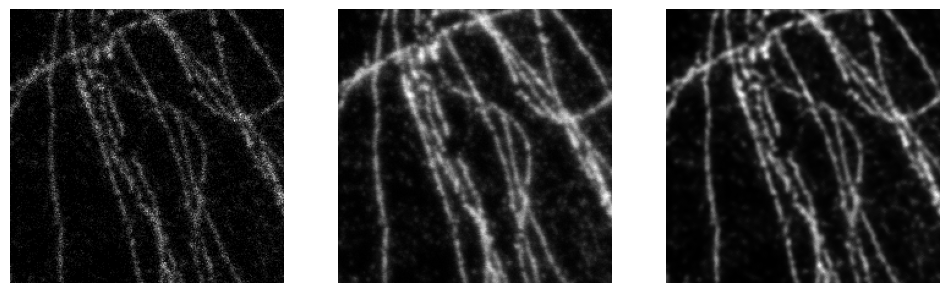

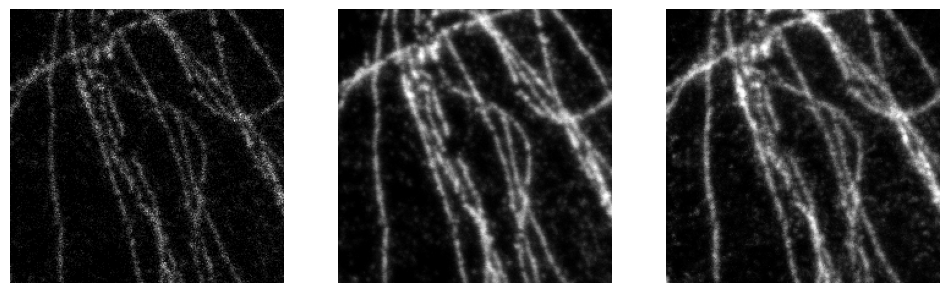

Processing method: UNet-RCAN


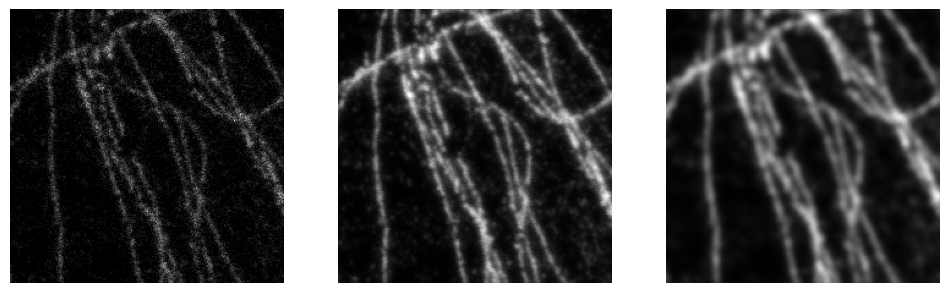

Processing method: IMAGENET1K_V1


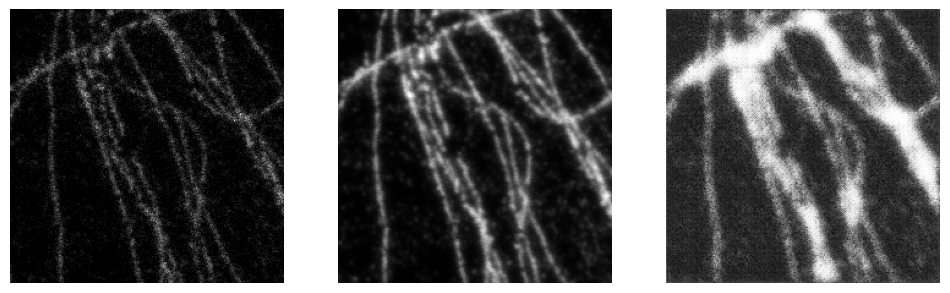

Processing method: JUMP


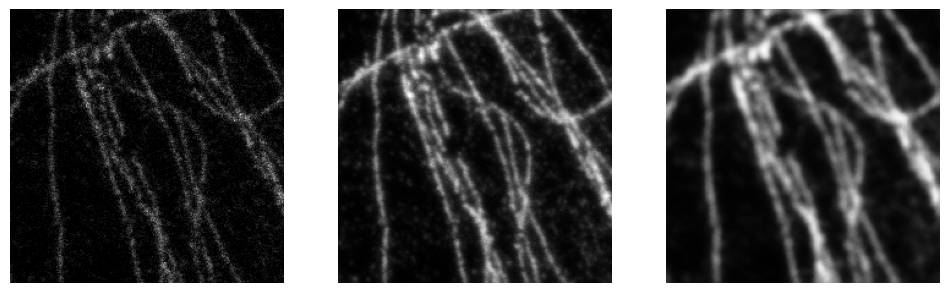

Processing method: HPA


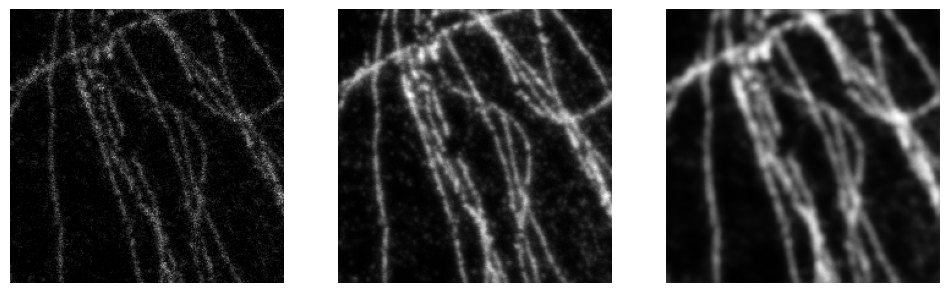

Processing method: SIM


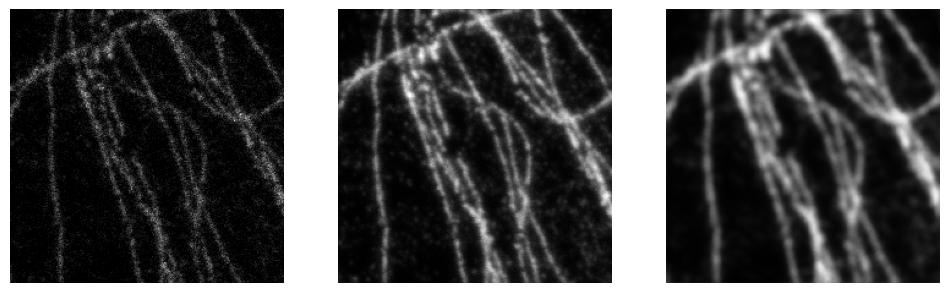

Processing method: STED


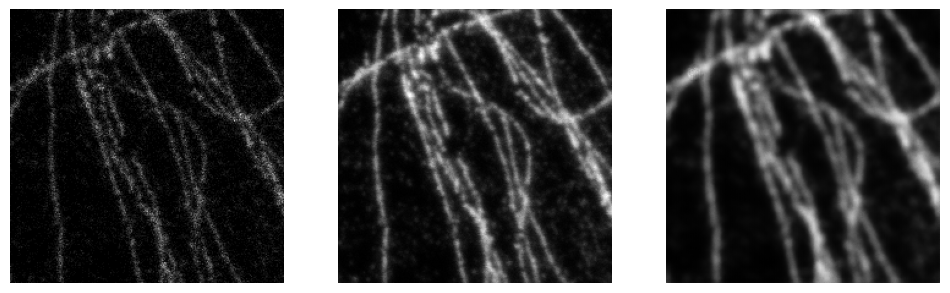

In [28]:
os.makedirs("examples", exist_ok=True)
idx = 3
for i, method in enumerate(methods[:2]):
    if method in ["STED", "SIM", "HPA", "JUMP", "IMAGENET1K_V1"]:
        continue

    gt_images = get_ground_truth_images(dataset)
    raw_images = get_raw_images(dataset, gt_images)
    gt_images, predicted_images = get_predicted_images(method, dataset, gt_images)

    gt_images = load_images(gt_images)
    raw_images = load_images(raw_images)
    predicted_images = load_images(predicted_images)

    fig, axes = pyplot.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(raw_images[idx, 0, :224, :224], cmap="gray")
    axes[1].imshow(gt_images[idx, 0, :224, :224], cmap="gray")
    axes[2].imshow(predicted_images[idx, 0, :224, :224], cmap="gray")
    for ax in axes:
        ax.axis("off")
    pyplot.show()


    if i == 0:
        original_shape = gt_images.shape
        gt_image_ref = gt_images[idx, 0, :224, :224].copy()

        tifffile.imwrite(
            os.path.join("examples", f"{dataset}-raw.tif"),
            make_composite(raw_images[idx, 0, :224, :224][numpy.newaxis], luts=["gray"], ranges=[(0, 1)]).astype(numpy.uint8),
        )
        tifffile.imwrite(
            os.path.join("examples", f"{dataset}-gt.tif"),
            make_composite(gt_images[idx, 0, :224, :224][numpy.newaxis], luts=["gray"], ranges=[(0, 1)]).astype(numpy.uint8),
        )
    tifffile.imwrite(
        os.path.join("examples", f"{dataset}-{method}.tif"),
        make_composite(predicted_images[idx, 0, :224, :224][numpy.newaxis], luts=["gray"], ranges=[(0, 1)]).astype(numpy.uint8),
    )

method = "pix2pix"
gt_images = get_ground_truth_images(dataset)
raw_images = get_raw_images(dataset, gt_images)
gt_images, predicted_images = get_predicted_images(method, dataset, gt_images)

gt_images = load_images(gt_images)
raw_images = load_images(raw_images)
predicted_images = load_images(predicted_images)

gt_images = resize(gt_images, original_shape, preserve_range=True, anti_aliasing=False).astype(gt_images.dtype)
predicted_images = resize(predicted_images, original_shape, preserve_range=True, anti_aliasing=False).astype(predicted_images.dtype)

fig, axes = pyplot.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(raw_images[idx, 0, :224, :224], cmap="gray")
axes[1].imshow(gt_images[idx, 0, :224, :224], cmap="gray")
axes[2].imshow(predicted_images[idx, 0, :224, :224], cmap="gray")
for ax in axes:
    ax.axis("off")
pyplot.show()

tifffile.imwrite(
        os.path.join("examples", f"{dataset}-{method}.tif"),
        make_composite(predicted_images[idx, 0, :224, :224][numpy.newaxis], luts=["gray"], ranges=[(0, 1)]).astype(numpy.uint8),
    )

for method in methods[3:]:
    print(f"Processing method: {method}")

    gt_images = get_ground_truth_images(dataset)
    raw_images = get_raw_images(dataset, gt_images)
    gt_images, predicted_images = get_predicted_images(method, dataset, gt_images)

    gt_images = load_images(gt_images)
    raw_images = load_images(raw_images)
    predicted_images = load_images(predicted_images)

    min_idx = -1
    min_val = float("inf")
    for i, image in enumerate(gt_images):
        diff = numpy.sum(numpy.abs(image[0] - gt_image_ref))
        if diff < min_val:
            min_idx = i
            min_val = diff

    fig, axes = pyplot.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(raw_images[idx, 0, :224, :224], cmap="gray", vmin=0, vmax=1)
    axes[1].imshow(gt_images[min_idx, 0], cmap="gray", vmin=0, vmax=1)
    axes[2].imshow(predicted_images[min_idx, 0], cmap="gray", vmin=0, vmax=1)
    for ax in axes:
        ax.axis("off")
    pyplot.show()

    tifffile.imwrite(
        os.path.join("examples", f"{dataset}-{method}.tif"),
        make_composite(predicted_images[min_idx, 0, :224, :224][numpy.newaxis], luts=["gray"], ranges=[(0, 1)]).astype(numpy.uint8),
    )